In [5]:
import pandas as pd
import numpy as np
import hist
import matplotlib as mpl
import mplhep
#import mplhep.error_estimation will come back to this later
mpl.style.use(mplhep.style.ROOT)
import matplotlib.pyplot as plt

In [4]:
import os
os.getcwd()

'/export/scratch/users/rodr1001/my_code/my_code/ldmx/hgcroc/pedestal_data/data'

In [6]:
pedestal = pd.read_csv('10k_pedestal_20250606_165534.csv')

In [7]:
pedestal.head()

,i_link,bx,event,orbit,channel,Tp,Tc,adc_tm1,adc,tot,toa
0,0,14,57,4,calib,False,False,215,219,-1,0
1,0,14,57,4,0,False,False,198,198,-1,0
2,0,14,57,4,1,False,False,162,159,-1,0
3,0,14,57,4,2,False,False,163,163,-1,0
4,0,14,57,4,3,False,False,181,183,-1,0


In [8]:
pedestal.describe()

,i_link,bx,event,orbit,adc_tm1,adc,tot,toa
count,740000.0,740000.0,740000.000000,740000.0000,740000.000000,740000.000000,740000.0,740000.0
mean,0.5,14.0,31.458100,3.5015,209.262035,209.272012,-1.0,0.0
std,0.5,0.0,18.472707,2.2919,19.201545,19.201431,0.0,0.0
min,0.0,14.0,0.000000,0.0000,130.000000,157.000000,-1.0,0.0
25%,0.0,14.0,15.000000,2.0000,197.000000,197.000000,-1.0,0.0
50%,0.5,14.0,31.000000,3.0000,209.000000,209.000000,-1.0,0.0
75%,1.0,14.0,47.000000,6.0000,223.000000,223.000000,-1.0,0.0
max,1.0,14.0,63.000000,7.0000,255.000000,255.000000,-1.0,0.0


In [26]:
# define a unique ID for each channel to make histograms a bit easier to make
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']

In [27]:
pedestal.head()

,i_link,bx,event,orbit,channel,Tp,Tc,adc_tm1,adc,tot,toa,uid
0,0,14,57,4,calib,False,False,215,219,-1,0,0_calib
1,0,14,57,4,0,False,False,198,198,-1,0,0_0
2,0,14,57,4,1,False,False,162,159,-1,0,0_1
3,0,14,57,4,2,False,False,163,163,-1,0,0_2
4,0,14,57,4,3,False,False,181,183,-1,0,0_3


In [11]:
def fill_and_plot_all_channels(
    xname, xlabel, xmin, xmax, rebin=1
):
    plt.figure(figsize=(20,10))
    (
        hist.Hist.new
        .StrCategory(pedestal['uid'].unique(), label='Link_Channel')
        .Reg((xmax-xmin)//rebin,xmin,xmax, label=xlabel)
        .Double()
    ).fill(
        pedestal['uid'],
        pedestal[xname]
    ).plot2d(
        cmin=1,
        cbarsize=0.7
    )
    plt.xticks(rotation=90, size='x-small')
    plt.show()

In [12]:
pedestal[['adc','adc_tm1','tot','toa']].max()

adc        255
adc_tm1    255
tot         -1
toa          0
dtype: int64

In [13]:
pedestal[['adc','adc_tm1','tot','toa']].min()

adc        157
adc_tm1    130
tot         -1
toa          0
dtype: int64

Min ADC is 157, Max is 255
Min ADC T-1 is 130, max is 255

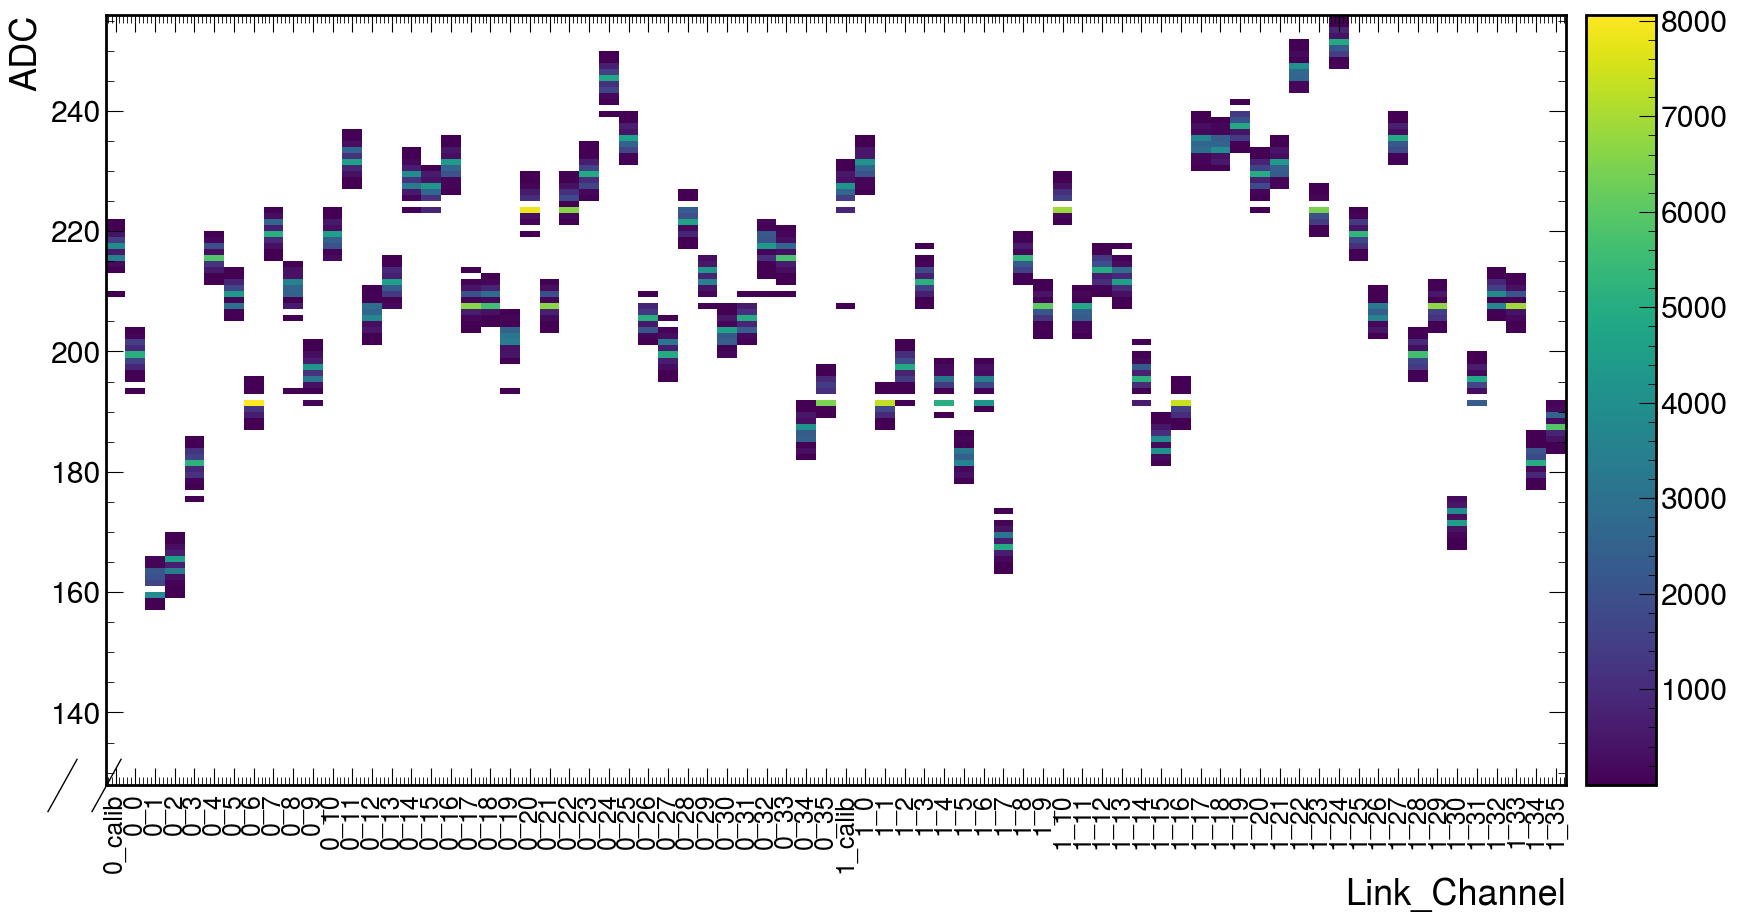

In [14]:

fill_and_plot_all_channels('adc','ADC',128,256)

In [61]:
link_0 = pedestal[pedestal['i_link'] ==0]
link_1 = pedestal[pedestal['i_link'] ==1]


In [39]:
link_1

,i_link,bx,event,orbit,channel,Tp,Tc,adc_tm1,adc,tot,toa,uid
37,1,14,57,4,calib,False,False,226,227,-1,0,1_calib
38,1,14,57,4,0,False,False,231,231,-1,0,1_0
39,1,14,57,4,1,False,False,191,191,-1,0,1_1
40,1,14,57,4,2,False,False,198,197,-1,0,1_2
41,1,14,57,4,3,False,False,210,211,-1,0,1_3
...,...,...,...,...,...,...,...,...,...,...,...,...
739995,1,14,48,3,31,False,False,194,197,-1,0,1_31
739996,1,14,48,3,32,False,False,207,209,-1,0,1_32
739997,1,14,48,3,33,False,False,207,206,-1,0,1_33
739998,1,14,48,3,34,False,False,181,181,-1,0,1_34


In [62]:
link_0_norm =link_0[link_0['channel'] != 'calib']
link_1_norm =link_1[link_1['channel'] != 'calib']

In [46]:
link_0_norm

,i_link,bx,event,orbit,channel,Tp,Tc,adc_tm1,adc,tot,toa,uid
1,0,14,57,4,0,False,False,198,198,-1,0,0_0
2,0,14,57,4,1,False,False,162,159,-1,0,0_1
3,0,14,57,4,2,False,False,163,163,-1,0,0_2
4,0,14,57,4,3,False,False,181,183,-1,0,0_3
5,0,14,57,4,4,False,False,215,215,-1,0,0_4
...,...,...,...,...,...,...,...,...,...,...,...,...
739958,0,14,48,3,31,False,False,205,205,-1,0,0_31
739959,0,14,48,3,32,False,False,217,219,-1,0,0_32
739960,0,14,48,3,33,False,False,215,214,-1,0,0_33
739961,0,14,48,3,34,False,False,187,188,-1,0,0_34


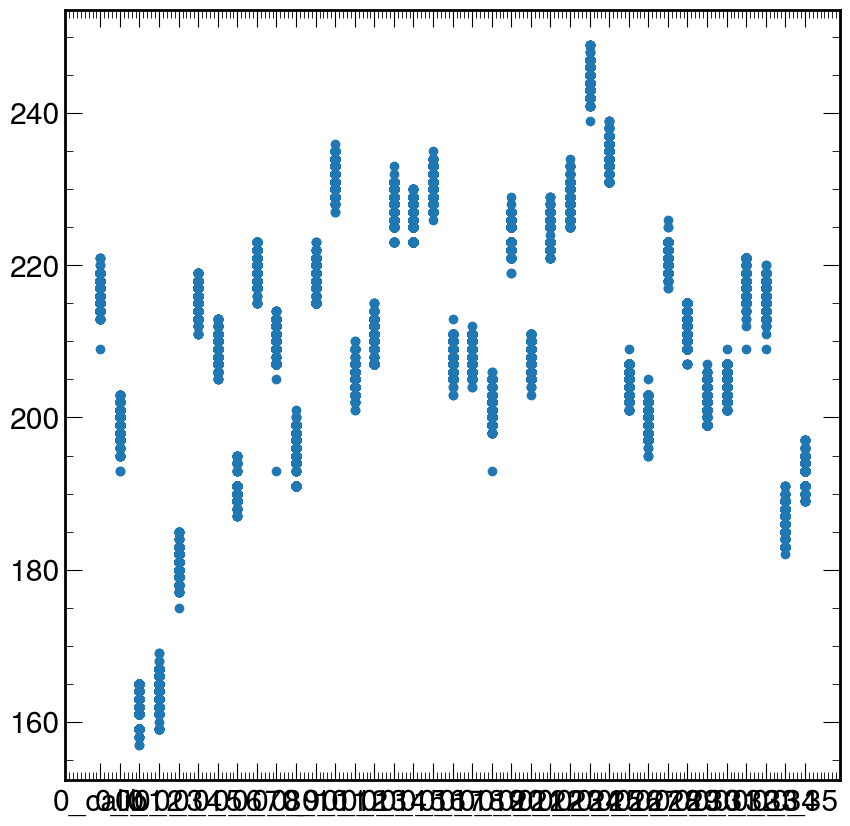

In [49]:
plt.scatter(link_0.uid,link_0.adc)

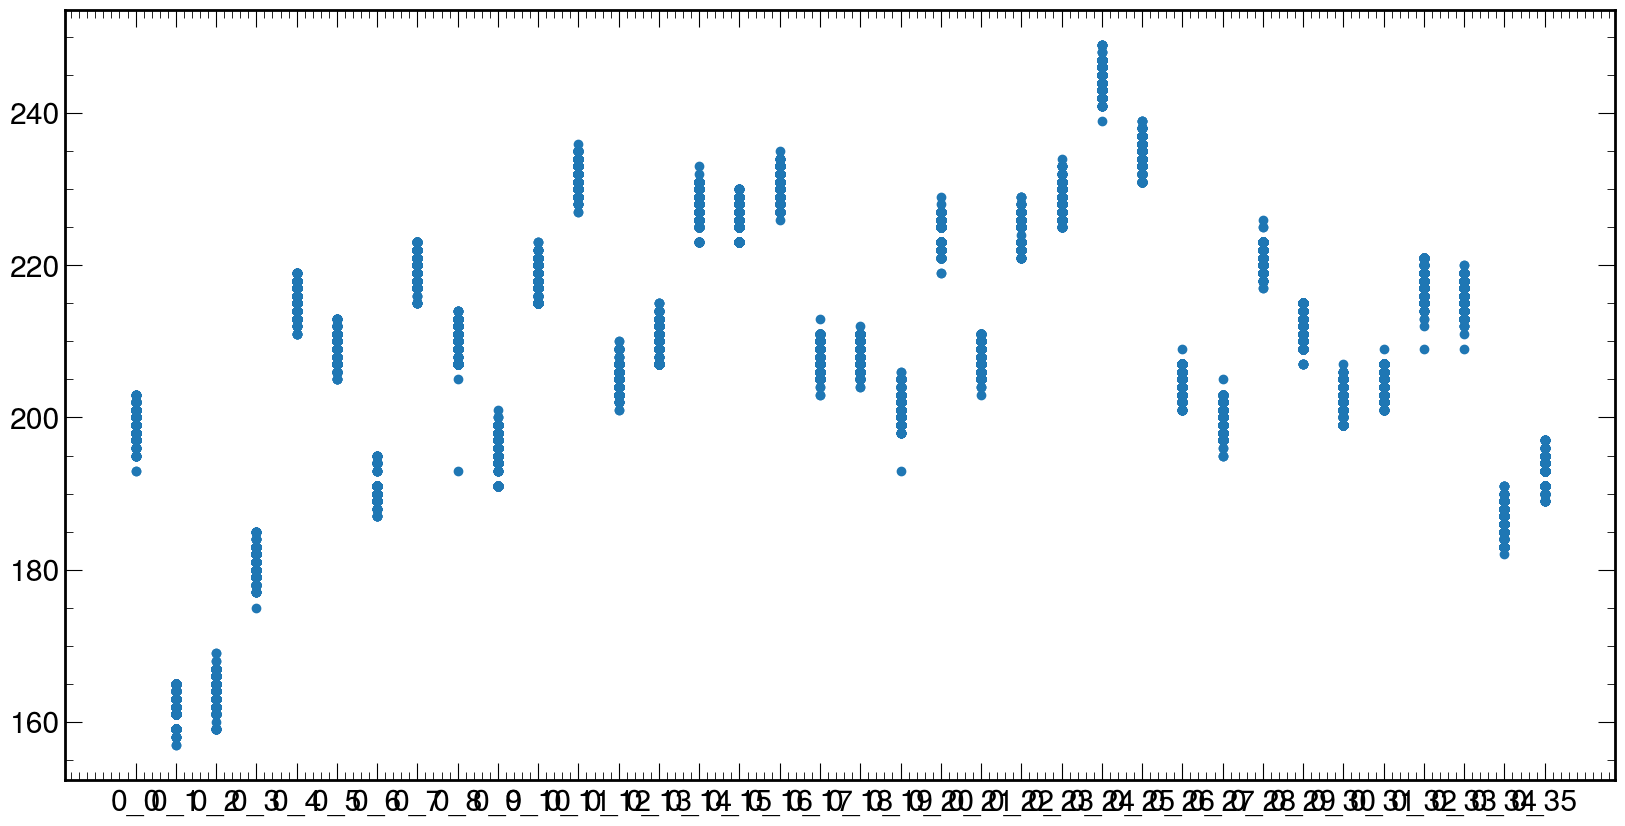

In [51]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)

In [72]:
link_0_norm.channel

1          0
2          1
3          2
4          3
5          4
          ..
739958    31
739959    32
739960    33
739961    34
739962    35
Name: channel, Length: 360000, dtype: object

In [58]:
link_0_norm['adc'].median()


209.0

In [59]:
link_0_norm['adc'].mean()

209.2594222222222

ADC mean for Link 0, barring calibration channels, from pandas, mean gives 209.259422, median gives 209.0, note that ADC max without calibration channels is different.  Min is 157, as before, Max 249, down from 255

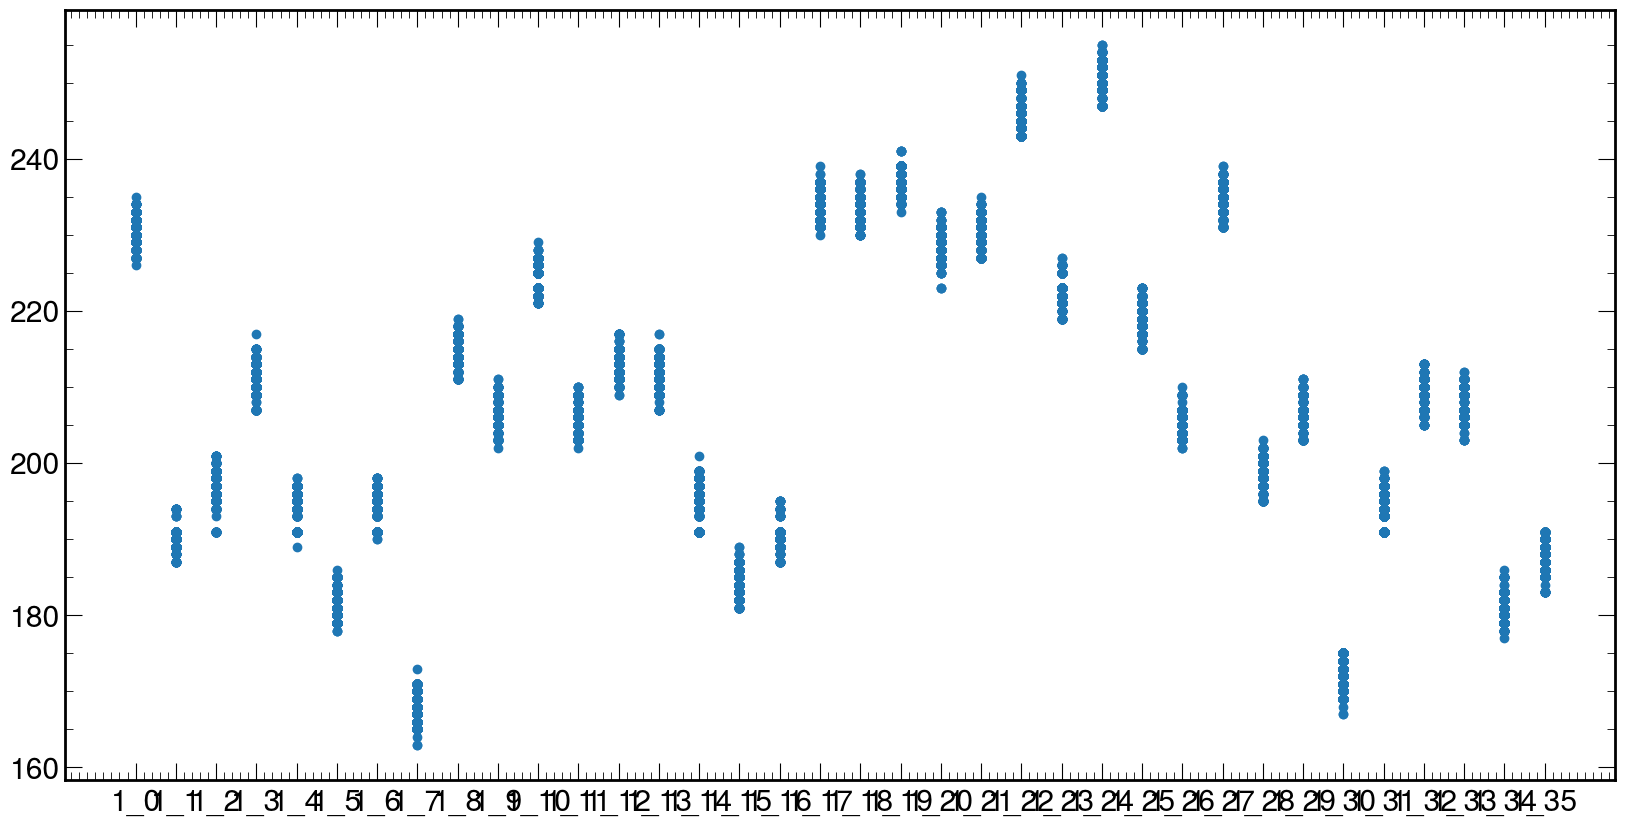

In [63]:
plt.figure(figsize=(20,10))
plt.scatter(link_1_norm.uid,link_1_norm.adc)

In [64]:
link_1_norm['adc'].median()


207.0

In [65]:
link_1_norm['adc'].mean()

208.61465

In [66]:
link_1_norm['adc'] == 0

38        False
39        False
40        False
41        False
42        False
          ...  
739995    False
739996    False
739997    False
739998    False
739999    False
Name: adc, Length: 360000, dtype: bool

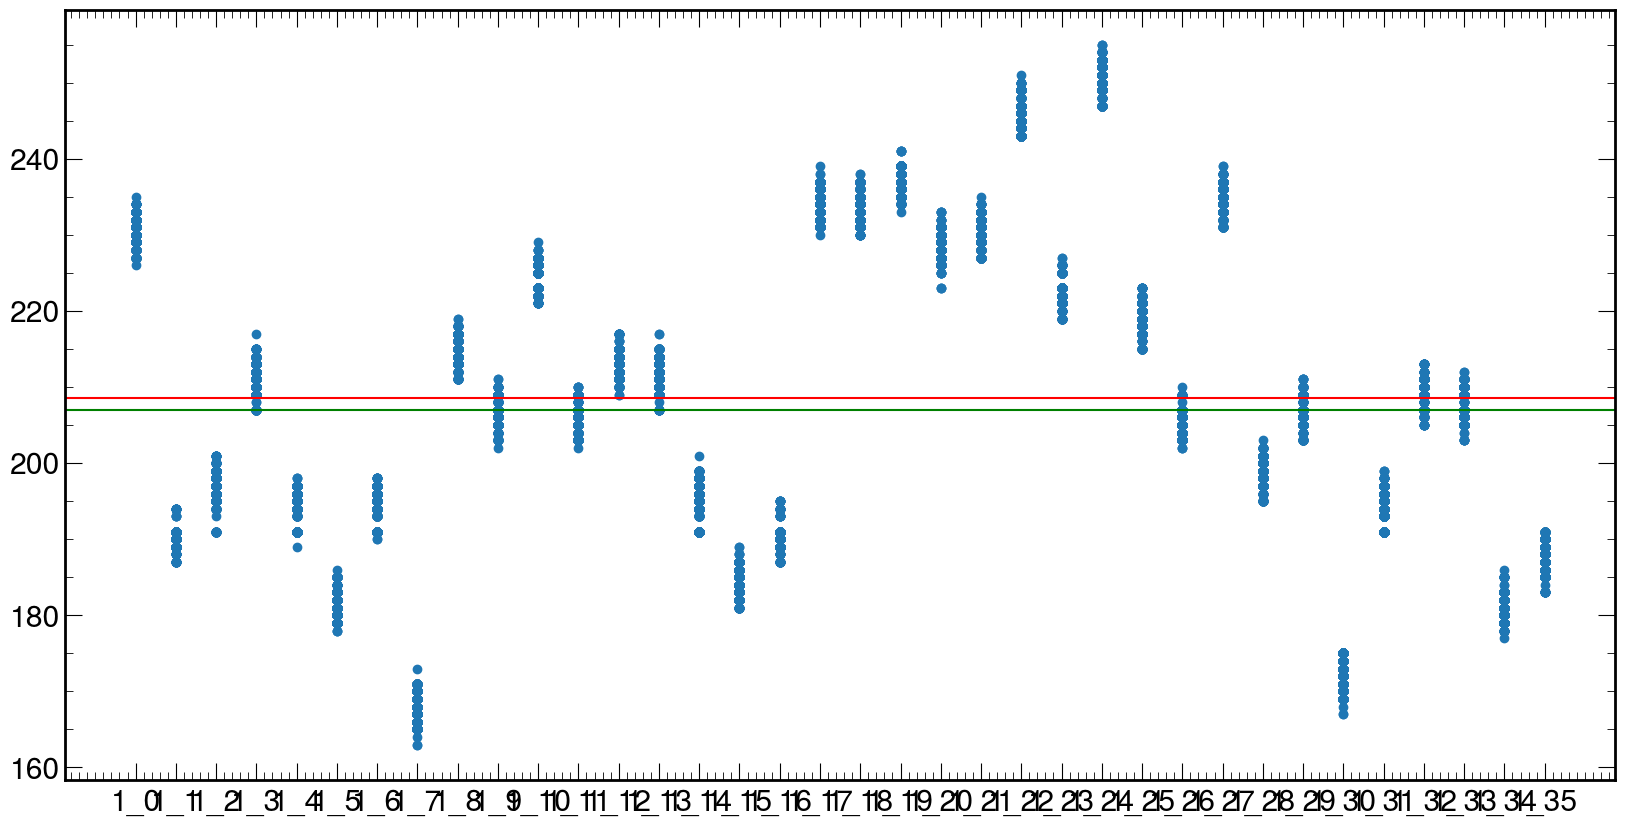

In [67]:
plt.figure(figsize=(20,10))
plt.scatter(link_1_norm.uid,link_1_norm.adc)
plt.axhline(y=(link_1_norm['adc'].mean()), color='r')
plt.axhline(y = (link_1_norm['adc'].median()), color = 'g')

In [79]:
link_0_norm.head()

,i_link,bx,event,orbit,channel,Tp,Tc,adc_tm1,adc,tot,toa,uid
1,0,14,57,4,0,False,False,198,198,-1,0,0_0
2,0,14,57,4,1,False,False,162,159,-1,0,0_1
3,0,14,57,4,2,False,False,163,163,-1,0,0_2
4,0,14,57,4,3,False,False,181,183,-1,0,0_3
5,0,14,57,4,4,False,False,215,215,-1,0,0_4


In [81]:
channel_0 = link_0_norm[link_0_norm['channel'] == '0'] #channel numbers aren't numbers, they're strings 

In [83]:
channel_0['adc'].mean()

199.0694

In [84]:
channel_0['adc'].median()

199.0

In [105]:
link_0_norm[link_0_norm['channel'] == str(i)]['adc'].mean()

199.0694

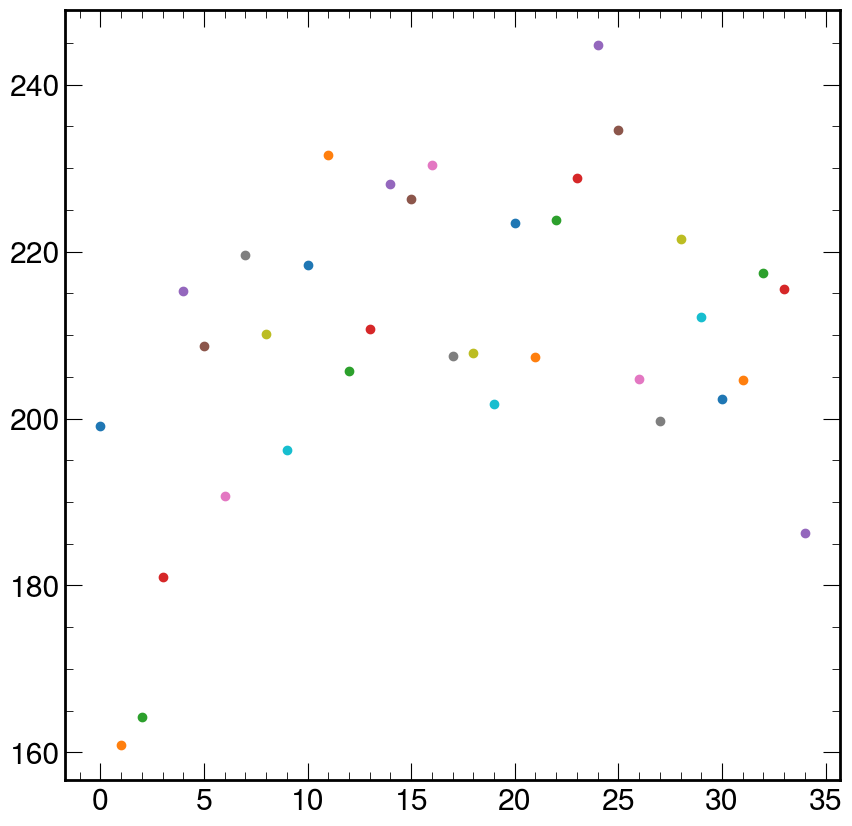

In [111]:
l0_channel_mean = []
for i in range(35):
    mean = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].mean()
    plt.scatter(x = i, y = mean )
    l0_channel_mean.append(mean)

In [112]:
link_0_mean = np.average(l0_channel_mean)


In [113]:
link_0_mean

209.75182857142855

In [121]:
link_1_norm['channel']

38         0
39         1
40         2
41         3
42         4
          ..
739995    31
739996    32
739997    33
739998    34
739999    35
Name: channel, Length: 360000, dtype: object

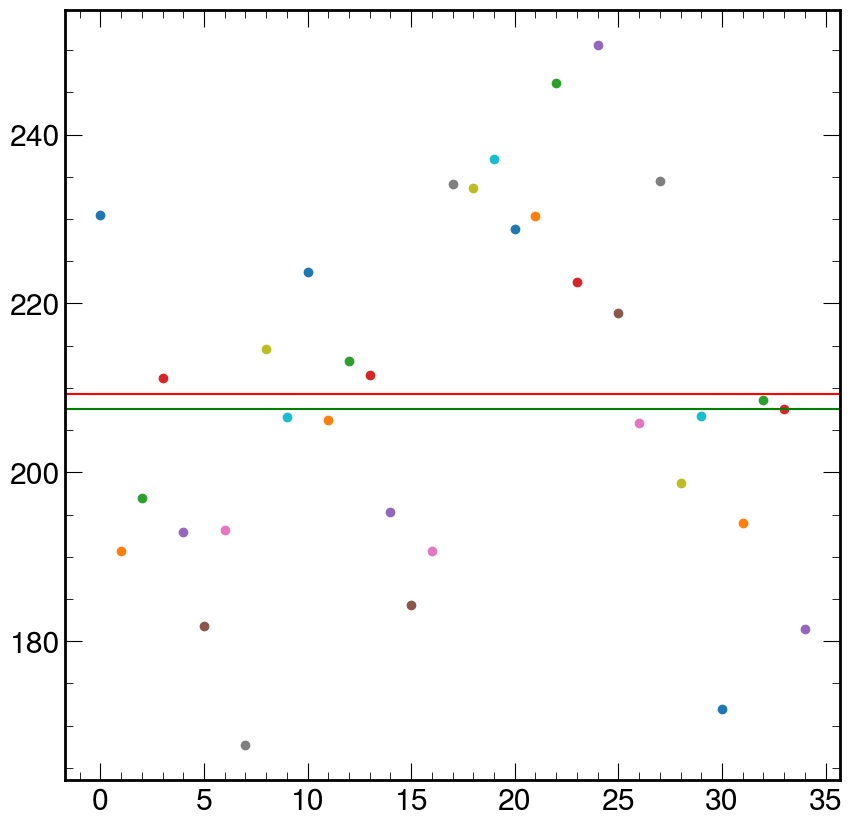

In [127]:
l1_channel_mean = [] #the mean ADC of each channel, in order from 0 to 35
for i in range(35):
    mean = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].mean()
    plt.scatter(x = i, y = mean )
    l1_channel_mean.append(mean)
link_1_mean = np.average(l1_channel_mean) # mean of list of mean ADCs of each channel
link_1_median= np.median(l1_channel_mean) #median of the mean ADC list
plt.axhline(y=link_1_mean, color='r')
plt.axhline(y=link_1_median, color='g')


In [128]:
link_1_mean = np.average(l1_channel_mean)
link_1_median

207.4744

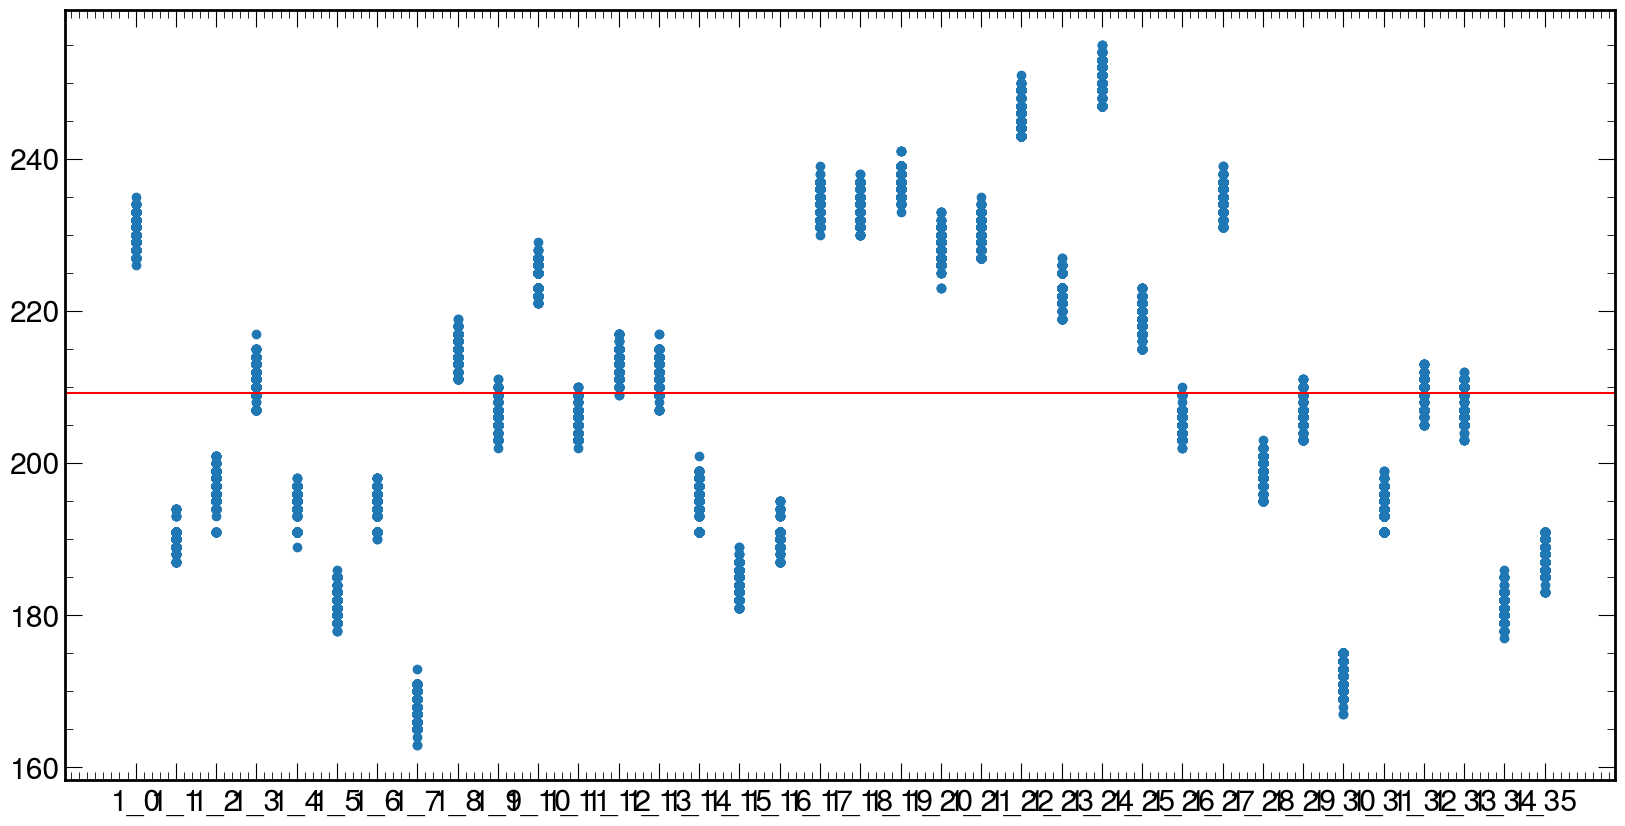

In [125]:
plt.figure(figsize=(20,10))
plt.scatter(link_1_norm.uid,link_1_norm.adc)
plt.axhline(y=link_1_mean, color='r')
#plt.axhline(y = (link_1_norm['adc'].median()), color = 'g')